# Tarea 6 — Optimización
**Carlos Andres Tovar · 202311530**

In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 1: Frontera de Pareto — 4 objetivos

### 1. Dominio de búsqueda y funciones objetivo

In [6]:
N = 100  # puntos por dimensión → 100×100 = 10 000 soluciones
x_vals = np.linspace(-10, 10, N)
y_vals = np.linspace(-10, 10, N)
X, Y   = np.meshgrid(x_vals, y_vals)
x, y   = X.ravel(), Y.ravel()

f1 = x**2 + y**2
f2 = (x - 4)**2 + (y - 4)**2
f3 = np.sin(x) + np.cos(y)
f4 = np.abs(x - y)

F = np.column_stack([f1, f2, f3, f4])   # (10 000, 4)

### 2. Algoritmo de dominancia de Pareto

In [7]:
def pareto_mask(F):
    """
    Retorna máscara booleana: True si el punto es NO dominado.
    El punto i es dominado si existe j tal que F[j] <= F[i] en todo
    objetivo y F[j] < F[i] en al menos uno.
    """
    n = len(F)
    is_dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        if is_dominated[i]:
            continue
        diff = F - F[i]
        leq  = np.all(diff <= 0, axis=1)
        lt   = np.any(diff <  0, axis=1)
        dominated_by = leq & lt
        dominated_by[i] = False
        if np.any(dominated_by):
            is_dominated[i] = True
    return ~is_dominated


mask        = pareto_mask(F)
F_pareto    = F[mask]
F_dominados = F[~mask]

print(f"Total puntos        : {len(F)}")
print(f"No dominados (PF*) : {mask.sum()}  ({100 * mask.mean():.1f} %)")
print(f"Dominados           : {(~mask).sum()}")

Total puntos        : 10000
No dominados (PF*) : 422  (4.2 %)
Dominados           : 9578


### 3. Visualización — 6 proyecciones de PF*

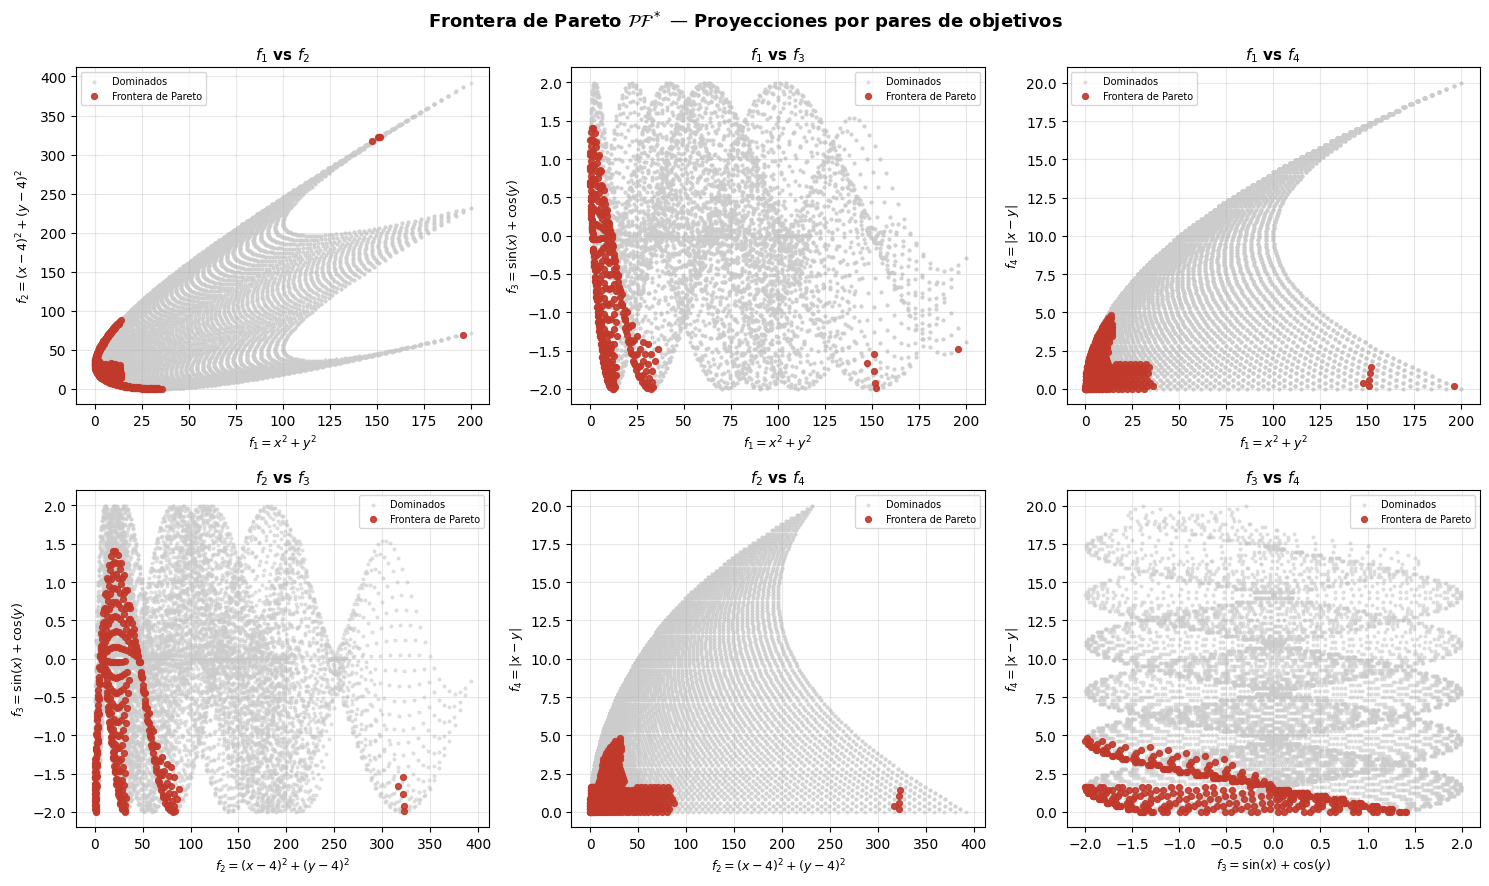

In [8]:
labels = [r"$f_1 = x^2 + y^2$",
          r"$f_2 = (x-4)^2 + (y-4)^2$",
          r"$f_3 = \sin(x) + \cos(y)$",
          r"$f_4 = |x - y|$"]

pares = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(r"Frontera de Pareto $\mathcal{PF}^*$ — Proyecciones por pares de objetivos",
             fontsize=13, fontweight='bold')

for ax, (i, j) in zip(axes.ravel(), pares):
    ax.scatter(F_dominados[:, i], F_dominados[:, j],
               c='#cccccc', s=4, alpha=0.5, label='Dominados')
    ax.scatter(F_pareto[:, i], F_pareto[:, j],
               c='#c0392b', s=18, alpha=0.9, zorder=3, label='Frontera de Pareto')
    ax.set_xlabel(labels[i], fontsize=9)
    ax.set_ylabel(labels[j], fontsize=9)
    ax.set_title(f"$f_{{{i+1}}}$ vs $f_{{{j+1}}}$", fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Ejercicio 2: Interpretación geométrica — Condiciones KKT

### 1. Grilla y región factible

In [9]:
x = np.linspace(-0.5, 4.5, 400)
y = np.linspace(-0.5, 4.5, 400)
X, Y = np.meshgrid(x, y)

F        = X**2 + Y**2 - 4*X - 6*Y          # función objetivo
factible = (X + Y <= 4) & (X >= 0) & (Y >= 0)

### 2. Visualización

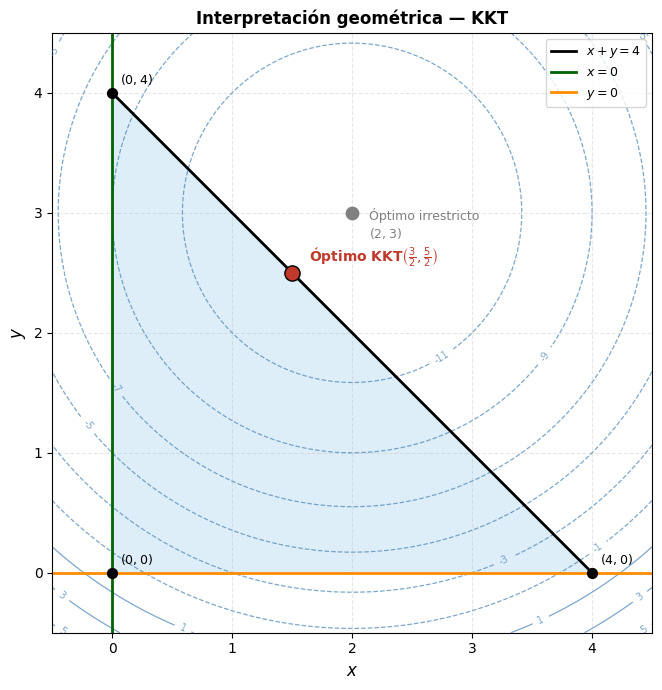

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

# ── Curvas de nivel ───────────────────────────────────────────────────────────
niveles = np.arange(-13, 10, 2)
cs = ax.contour(X, Y, F, levels=niveles,
                colors='steelblue', linewidths=0.9, alpha=0.7)
ax.clabel(cs, fontsize=7, fmt='%.0f')

# ── Región factible sombreada ─────────────────────────────────────────────────
ax.contourf(X, Y, factible.astype(float), levels=[0.5, 1.5],
            colors=['#aed6f1'], alpha=0.4)

# ── Frontera de la región factible ────────────────────────────────────────────
x_g1 = np.linspace(0, 4, 200)
ax.plot(x_g1, 4 - x_g1, 'k-',         lw=2, label='$x + y = 4$')
ax.axvline(0,  color='darkgreen',      lw=2, label='$x = 0$')
ax.axhline(0,  color='darkorange',     lw=2, label='$y = 0$')

# ── Puntos clave ──────────────────────────────────────────────────────────────
# Óptimo irrestricto (2, 3) — fuera de la región factible
ax.scatter(2, 3, c='gray', s=80, zorder=5)
ax.annotate('Óptimo irrestricto\n$(2, 3)$', (2, 3),
            textcoords="offset points", xytext=(12, -18),
            fontsize=9, color='gray')

# Óptimo KKT (3/2, 5/2) — sobre la restricción activa x+y=4
ax.scatter(3/2, 5/2, c='#c0392b', s=120, zorder=6,
           edgecolors='black', lw=1)
ax.annotate(r'Óptimo KKT$\left(\frac{3}{2}, \frac{5}{2}\right)$',
            (3/2, 5/2), textcoords="offset points", xytext=(12, 8),
            fontsize=10, color='#c0392b', fontweight='bold')

# Vértices de la región factible
for px, py, txt in [(0, 0, '$(0,0)$'), (4, 0, '$(4,0)$'), (0, 4, '$(0,4)$')]:
    ax.scatter(px, py, c='black', s=50, zorder=5)
    ax.annotate(txt, (px, py), textcoords="offset points",
                xytext=(6, 6), fontsize=9)

# ── Formato ───────────────────────────────────────────────────────────────────
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 4.5)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y$', fontsize=12)
ax.set_title('Interpretación geométrica — KKT', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()